# 1. Executive Summary

# 2. Bussiness Understanding

### Summary
"Our telecom company wants to reduce churn. We will predict which customers are likely to churn and suggest targeted retention strategies."

### Metrics
- Churn rate
- Distribution of numeric features
- Basic correlation insights

# 3. Data Overview

## Setup

In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style='whitegrid')
%matplotlib inline

## Data Loading

In [2]:
#I have downloaded the data set from https://www.kaggle.com/datasets/blastchar/telco-customer-churn
#I have renamed the file telco_churn.csv and set in the proper directory
df = pd.read_csv('telco_churn.csv')
#Let us look at the head of the dataframe
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

In [3]:
#Let us look at the columns in the data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
#I check for missing values
print(df.isnull().sum().sum())
#Any duplicated values? Apparently not
print(df.duplicated().sum())

0
0


In [5]:
#Data types correct? Strings vs numbers.
df.info()
#No. Most of these should be numbers

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning

In [55]:
#I can convert TotalCharges to a numeric value
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("The type is now",df['TotalCharges'].dtype)
if df['TotalCharges'].isna().any():
    print("NaNs detected in TotalCharges after transform")

The type is now float64
NaNs detected in TotalCharges after transform


In [7]:
#Now, I want to give fields a correct type. Let me start with the binary columns
# For gender
if df['gender'].dtype == 'str':
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# For other binary columns
binary_columns=['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_columns:
    if df[col].dtype == 'str':
        df[col] = df[col].map({'Yes': 1, 'No': 0})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

In [8]:
#I wanna do some cleaning on MultipleLines
# Sanity check. Is every row with 'No phone service' also a row where 'PhoneService' is 0? 
(df.loc[df['MultipleLines'] == 'No phone service', 'PhoneService'] == 0).all()

np.True_

In [9]:
#Now do the transform
df['MultipleLines'] = (df['MultipleLines'] == 'Yes').astype(int)
#This is safe because 'No phone service' carries no additional info beyond PhoneService.

In [10]:
#I want to do something about the Internet service
# Step 1: Preserve original values only if not already preserved
if 'InternetService_Category' not in df.columns:
    df['InternetService_Category'] = df['InternetService']

# Step 2: Create a binary column safely
df['InternetService'] = (df['InternetService'] != 'No').astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerID                7043 non-null   str    
 1   gender                    7043 non-null   int64  
 2   SeniorCitizen             7043 non-null   int64  
 3   Partner                   7043 non-null   int64  
 4   Dependents                7043 non-null   int64  
 5   tenure                    7043 non-null   int64  
 6   PhoneService              7043 non-null   int64  
 7   MultipleLines             7043 non-null   int64  
 8   InternetService           7043 non-null   int64  
 9   OnlineSecurity            7043 non-null   str    
 10  OnlineBackup              7043 non-null   str    
 11  DeviceProtection          7043 non-null   str    
 12  TechSupport               7043 non-null   str    
 13  StreamingTV               7043 non-null   str    
 14  StreamingMovies    

In [11]:
internet_services = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in internet_services:
    # Only transform if the sanity check passes
    sanity_passed = (df.loc[df[col] == 'No internet service', 'InternetService'] == 0).all()
    
    if sanity_passed:
        # Idempotent binary conversion: 1 if 'Yes', 0 otherwise
        df[col] = (df[col] == 'Yes').astype(int)
    else:
        raise ValueError(f"Sanity check failed for {col}, not transforming")

In [12]:
#Now, I want to look at categorical columns
categorical_columns=['Contract','PaymentMethod','InternetService_Category']
#I can look at values for the different fields
for col in categorical_columns:
    print(df[col].value_counts(normalize=True))


Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64
PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64
InternetService_Category
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64


In [13]:
for col in categorical_columns:
    # One-hot encode and convert to int
    dummies = pd.get_dummies(df[col], prefix=col).astype(int)
    df = pd.concat([df, dummies], axis=1)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   str    
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   MultipleLines                            7043 non-null   int64  
 8   InternetService                          7043 non-null   int64  
 9   OnlineSecurity                           7043 non-null   int64  
 10  OnlineBackup                             7043 non-null   in

# 4. Exploratory Data Analysis

In [15]:
#We analyse the target distribution
df['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## Numerical Features

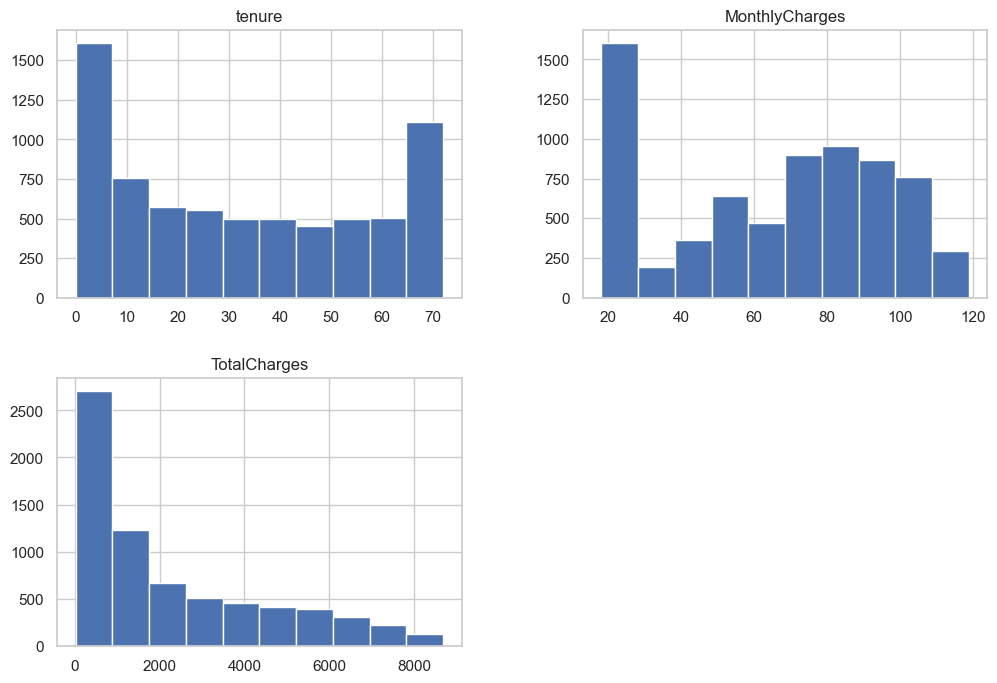

In [16]:
#I can look at some of the numeric features
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=10, figsize=(12,8))
plt.show()

## Categorical Features

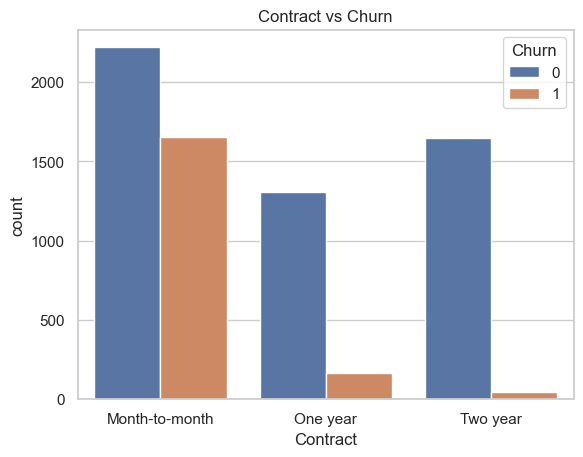

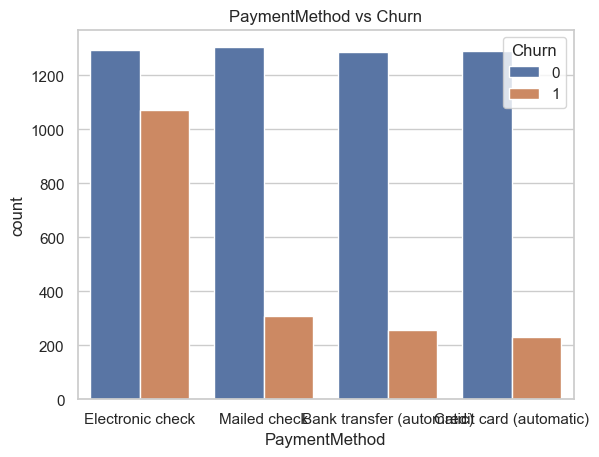

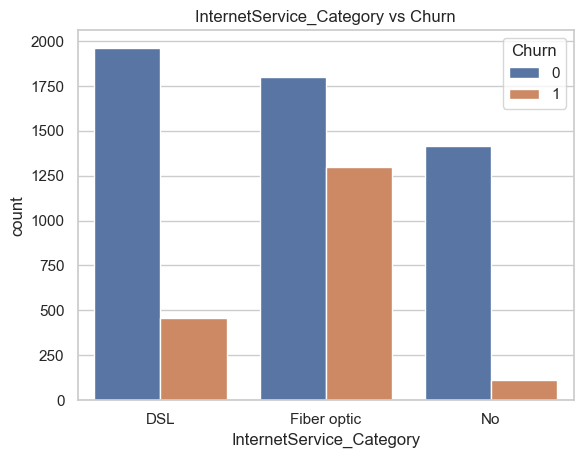

In [17]:
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService_Category']
for col in categorical_cols:
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.show()

## Correlations

In [18]:
df.select_dtypes(include='number').corr()['Churn'].sort_values(ascending=False)

Churn                                      1.000000
Contract_Month-to-month                    0.405103
InternetService_Category_Fiber optic       0.308020
PaymentMethod_Electronic check             0.301919
InternetService                            0.227890
MonthlyCharges                             0.193356
PaperlessBilling                           0.191825
SeniorCitizen                              0.150889
StreamingTV                                0.063228
StreamingMovies                            0.061382
MultipleLines                              0.040102
PhoneService                               0.011942
gender                                     0.008612
DeviceProtection                          -0.066160
OnlineBackup                              -0.082255
PaymentMethod_Mailed check                -0.091683
PaymentMethod_Bank transfer (automatic)   -0.117937
InternetService_Category_DSL              -0.124214
PaymentMethod_Credit card (automatic)     -0.134302
Partner     

# 5. Feature Engineering

### 1. Tenure Group

We bin customer tenure into lifecycle stages. Early-stage customers are typically more likely to churn.  
This feature captures nonlinear churn behavior across the customer lifecycle.

In [19]:
if 'tenure_group' not in df.columns:
    df['tenure_group'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
    )


### 2. New Customer Flag

Customers in their first year tend to have higher churn risk.
We create a binary feature identifying early-stage customers.


In [20]:
if 'is_new_customer' not in df.columns:
    df['is_new_customer'] = (df['tenure'] <= 12).astype(int)

### 3. Long-Term Contract Flag

Long-term contracts (1 or 2 years) significantly reduce churn.
We create a binary indicator for contractual commitment.


In [21]:
if 'is_long_term' not in df.columns:
    df['is_long_term'] = (
        df['Contract_One year'] + df['Contract_Two year']
    ).astype(int)

### 4. Auto-Pay Flag

Flags customers using automatic payment methods.

In [22]:
if 'auto_pay_flag' not in df.columns:
    df['auto_pay_flag'] = (
        df['PaymentMethod_Bank transfer (automatic)'] +
        df['PaymentMethod_Credit card (automatic)']
    ).astype(int)

### 5. Number of Services

Counts subscribed services to approximate engagement.


In [23]:
if 'num_services' not in df.columns:
    service_cols = [
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies'
    ]
    df['num_services'] = df[service_cols].sum(axis=1)

### 6. Average Revenue Per Month

Normalizes total charges by tenure to approximate monthly value.


In [24]:
if 'avg_revenue' not in df.columns:
    df['avg_revenue'] = df['TotalCharges'] / (df['tenure'] + 1)

### 7. High Monthly Charges Flag

Flags customers paying above the median monthly charge.


In [25]:
if 'high_monthly_flag' not in df.columns:
    median_charge = df['MonthlyCharges'].median()
    df['high_monthly_flag'] = (df['MonthlyCharges'] > median_charge).astype(int)

### 8. Family Flag

Binary indicator for customers with partner or dependents.


In [26]:
if 'family_flag' not in df.columns:
    df['family_flag'] = (
        (df['Partner'] + df['Dependents']) > 0
    ).astype(int)

### 9. Fiber Optic Flag

Explicitly isolates fiber optic customers.

In [27]:
if 'fiber_flag' not in df.columns:
    df['fiber_flag'] = df['InternetService_Category_Fiber optic']

### 10. Electronic Check Flag

Isolates customers using electronic check payments.

In [28]:
if 'electronic_check_flag' not in df.columns:
    df['electronic_check_flag'] = df['PaymentMethod_Electronic check']

## Interaction Features

### 1. Interaction: New Customer × Electronic Check

Identifies newly acquired customers paying via electronic check.


In [29]:
if 'new_echeck_interaction' not in df.columns:
    df['new_echeck_interaction'] = (
        df['is_new_customer'] * df['electronic_check_flag']
    )

### 2. Interaction: Fiber × High Monthly Charge

Captures high-paying fiber customers.



In [30]:
if 'fiber_highcharge_interaction' not in df.columns:
    df['fiber_highcharge_interaction'] = (
        df['fiber_flag'] * df['high_monthly_flag']
    )

### 3. Interaction: Long-Term Contract × Number of Services

Captures loyal and highly engaged customers.


In [31]:
if 'loyal_engaged_interaction' not in df.columns:
    df['loyal_engaged_interaction'] = (
        df['is_long_term'] * df['num_services']
    )


# 6. Modeling

## 6.1. Modeling Setup (Foundation)

### Target and Features Matrices

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   customerID                               7043 non-null   str     
 1   gender                                   7043 non-null   int64   
 2   SeniorCitizen                            7043 non-null   int64   
 3   Partner                                  7043 non-null   int64   
 4   Dependents                               7043 non-null   int64   
 5   tenure                                   7043 non-null   int64   
 6   PhoneService                             7043 non-null   int64   
 7   MultipleLines                            7043 non-null   int64   
 8   InternetService                          7043 non-null   int64   
 9   OnlineSecurity                           7043 non-null   int64   
 10  OnlineBackup                             7043 n

In [44]:
# 1. Target
y = df['Churn']

# 2. Feature selection
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_revenue']
engineered_features = [
    'is_new_customer', 'is_long_term', 'auto_pay_flag', 'num_services',
    'high_monthly_flag', 'family_flag', 'fiber_flag', 'electronic_check_flag',
    'new_echeck_interaction', 'fiber_highcharge_interaction', 'loyal_engaged_interaction'
]
categorical_features = ['Contract', 'PaymentMethod', 'InternetService_Category', 'tenure_group']

# 3. X matrix for all models
X = df[numeric_features + engineered_features + categorical_features]

# At this point X is just raw data; preprocessing will come later


In [46]:
X.info()
y.info

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   tenure                        7043 non-null   int64   
 1   MonthlyCharges                7043 non-null   float64 
 2   TotalCharges                  7032 non-null   float64 
 3   avg_revenue                   7032 non-null   float64 
 4   is_new_customer               7043 non-null   int64   
 5   is_long_term                  7043 non-null   int64   
 6   auto_pay_flag                 7043 non-null   int64   
 7   num_services                  7043 non-null   int64   
 8   high_monthly_flag             7043 non-null   int64   
 9   family_flag                   7043 non-null   int64   
 10  fiber_flag                    7043 non-null   int64   
 11  electronic_check_flag         7043 non-null   int64   
 12  new_echeck_interaction        7043 non-null   int64   
 13 

<bound method Series.info of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64>

### Train / Test Split

In [37]:
from sklearn.model_selection import train_test_split

# Split once for all models (stratify ensures class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [47]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   tenure                        7043 non-null   int64   
 1   MonthlyCharges                7043 non-null   float64 
 2   TotalCharges                  7032 non-null   float64 
 3   avg_revenue                   7032 non-null   float64 
 4   is_new_customer               7043 non-null   int64   
 5   is_long_term                  7043 non-null   int64   
 6   auto_pay_flag                 7043 non-null   int64   
 7   num_services                  7043 non-null   int64   
 8   high_monthly_flag             7043 non-null   int64   
 9   family_flag                   7043 non-null   int64   
 10  fiber_flag                    7043 non-null   int64   
 11  electronic_check_flag         7043 non-null   int64   
 12  new_echeck_interaction        7043 non-null   int64   
 13 

### Preprocessing Strategy

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# -------------------------------
# Reusable pipeline steps
# -------------------------------
median_imputer = SimpleImputer(strategy='median')
most_frequent_imputer = SimpleImputer(strategy='most_frequent')
missing_cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
scaler = StandardScaler()
ohe_drop_first = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_all = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# -------------------------------
# 1. Linear model preprocessing
# -------------------------------
num_pipeline_linear = Pipeline([
    ('imputer', median_imputer),
    ('scaler', scaler)
])

cat_pipeline_linear = Pipeline([
    ('imputer', missing_cat_imputer),
    ('encoder', ohe_drop_first)
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_linear, numeric_features + engineered_features),
        ('cat', cat_pipeline_linear, categorical_features)
    ]
)

# -------------------------------
# 2. Tree-based preprocessing
# -------------------------------
num_pipeline_tree = Pipeline([
    ('imputer', median_imputer)
])

cat_pipeline_tree = Pipeline([
    ('imputer', most_frequent_imputer),
    ('encoder', ohe_all)
])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_tree, numeric_features + engineered_features),
        ('cat', cat_pipeline_tree, categorical_features)
    ]
)

# 3. Fit and transform X matrices
X_train_linear = linear_preprocessor.fit_transform(X_train)
X_test_linear  = linear_preprocessor.transform(X_test)

X_train_tree   = tree_preprocessor.fit_transform(X_train)
X_test_tree    = tree_preprocessor.transform(X_test)

# Ready for modeling:
# LogisticRegression → X_train_linear / X_test_linear
# RandomForest / GradientBoosting → X_train_tree / X_test_tree


## 6.2. Baseline Models

In [41]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

### Logistic Regression (Linear model)


In [64]:
from sklearn.linear_model import LogisticRegression


# Instantiate baseline logistic regression
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Fit on preprocessed linear training data
logreg.fit(X_train_linear, y_train)

# Predict
y_pred_logreg = logreg.predict(X_test_linear)

y_proba_logreg = logreg.predict_proba(X_test_linear)[:, 1]
# Evaluate
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

Logistic Regression
Accuracy: 0.7899219304471257


ROC-AUC: 0.8416996047430829


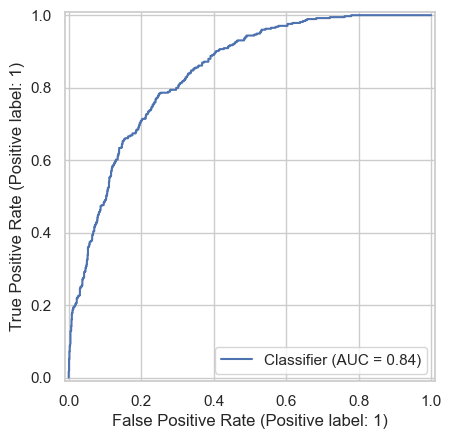

In [65]:
from sklearn.metrics import RocCurveDisplay
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))
RocCurveDisplay.from_predictions(y_test, y_proba_logreg)

In [66]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Random Forest (Tree model)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate baseline random forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Fit on tree-preprocessed data
rf.fit(X_train_tree, y_train)

# Predict
y_pred_rf = rf.predict(X_test_tree)
y_proba_rf = rf.predict_proba(X_test_tree)[:, 1]

# Evaluate
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7757274662881476
ROC-AUC: 0.8098181301506109
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



ROC-AUC: 0.8098181301506109


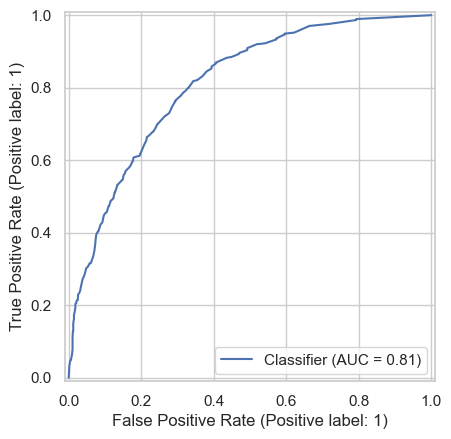

In [68]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
RocCurveDisplay.from_predictions(y_test, y_proba_rf)

In [69]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



### Gradient Boosting (Tree model)

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

# Instantiate baseline gradient boosting
gb = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)

# Fit on tree-preprocessed data
gb.fit(X_train_tree, y_train)

# Predict
y_pred_gb = gb.predict(X_test_tree)
y_proba_gb = gb.predict_proba(X_test_tree)[:, 1]

# Evaluate
print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.794889992902768


ROC-AUC: 0.8385259242036736


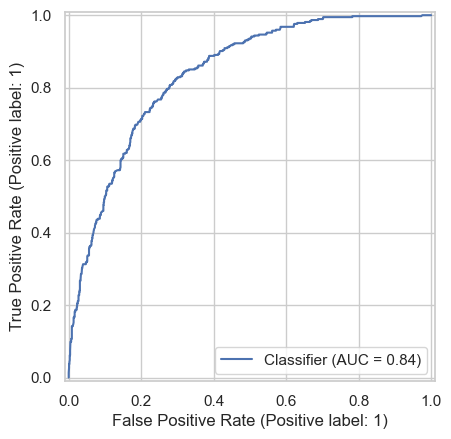

In [73]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))
RocCurveDisplay.from_predictions(y_test, y_proba_gb)

In [74]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



## 6.3. Evaluation

### Confusion Matrix

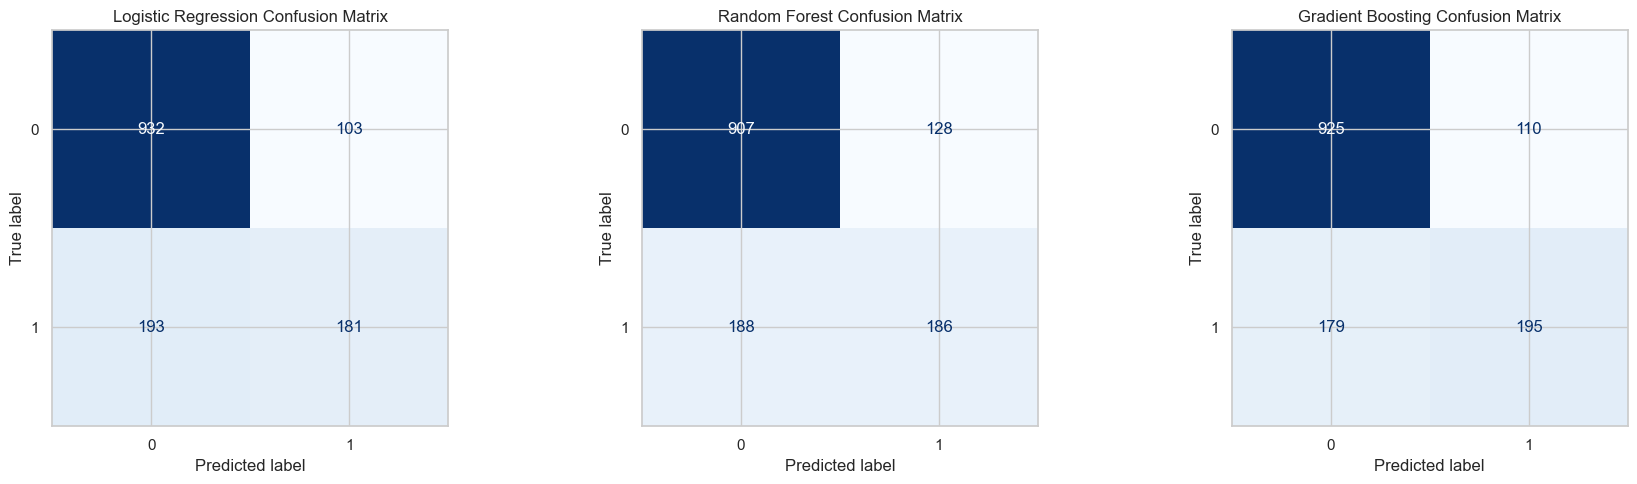

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prepare confusion matrices
cms = {
    "Logistic Regression": y_pred_logreg,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

for ax, (name, y_pred) in zip(axes, cms.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()



### Model Comparison

In [77]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Collect metrics in a dictionary
metrics = {
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
}

# Create a DataFrame for clean comparison
comparison_df = pd.DataFrame(metrics)
comparison_df

,Model,Accuracy,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.789922,0.841700,0.637324,0.483957,0.550152
1,Random Forest,0.775727,0.809818,0.592357,0.497326,0.540698
2,Gradient Boosting,0.794890,0.838526,0.639344,0.521390,0.574374


## 6.4. Initial Interpretation

### Logistic Regression

In [78]:
X_train_linear_df = pd.DataFrame(
    linear_preprocessor.transform(X_train),
    columns=list(numeric_features + engineered_features) +
            list(linear_preprocessor.named_transformers_['cat']
                 .named_steps['encoder'].get_feature_names_out(categorical_features))
)

In [79]:
X_train_linear_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 5634 non-null   float64
 1   MonthlyCharges                         5634 non-null   float64
 2   TotalCharges                           5634 non-null   float64
 3   avg_revenue                            5634 non-null   float64
 4   is_new_customer                        5634 non-null   float64
 5   is_long_term                           5634 non-null   float64
 6   auto_pay_flag                          5634 non-null   float64
 7   num_services                           5634 non-null   float64
 8   high_monthly_flag                      5634 non-null   float64
 9   family_flag                            5634 non-null   float64
 10  fiber_flag                             5634 non-null   float64
 11  electronic_chec

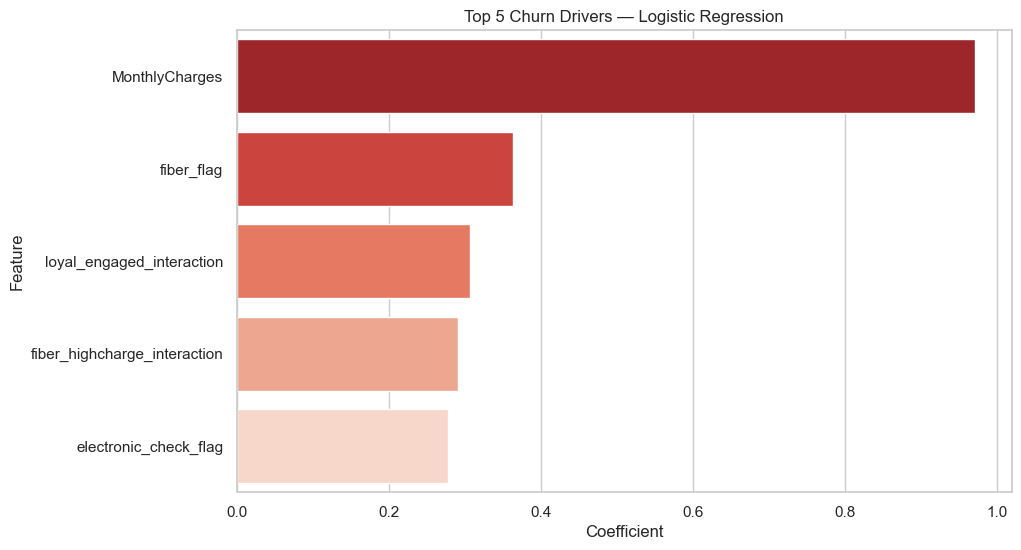

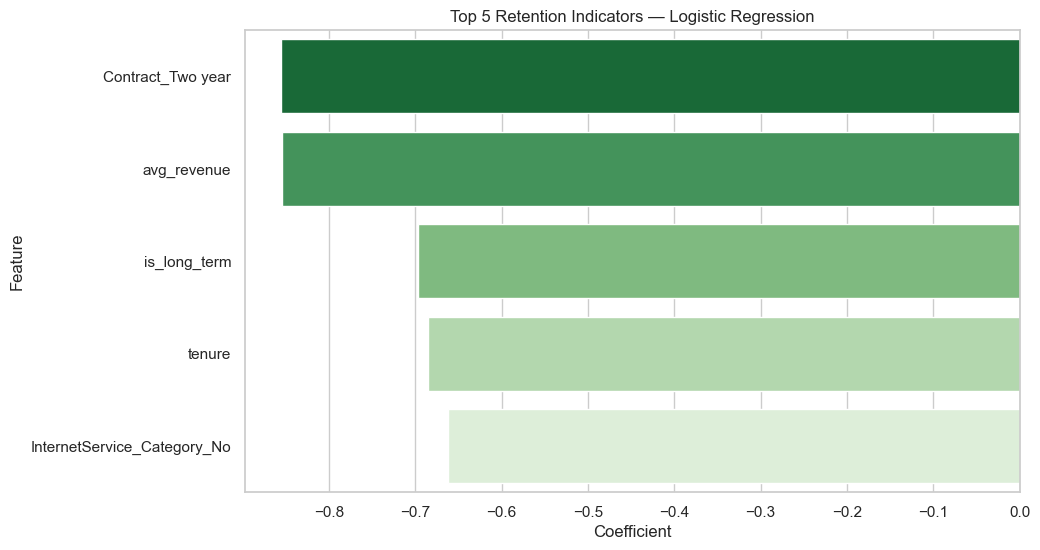

In [87]:
# Extract coefficients
coef_df = pd.DataFrame({
    "Feature": X_train_linear_df.columns,  # From your wrapped DataFrame
    "Coefficient": logreg.coef_[0]
})

# Top positive churn drivers
top_churn = coef_df.sort_values(by="Coefficient", ascending=False).head(5)

# Top retention indicators (negative coefficients)
top_retention = coef_df.sort_values(by="Coefficient").head(5)

# Plot top churn drivers
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=top_churn, palette="Reds_r", hue="Feature")
plt.title("Top 5 Churn Drivers — Logistic Regression")
plt.show()

# Plot top retention indicators
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=top_retention, palette="Greens_r", hue="Feature")
plt.title("Top 5 Retention Indicators — Logistic Regression")
plt.show()


### Logistic Regression Interpretation

- **Top Churn Drivers:** features with highest positive coefficients indicate increased likelihood of churn.  
- **Top Retention Indicators:** features with negative coefficients suggest lower churn risk.  

These results highlight which factors most influence customer behavior, providing actionable insight for retention strategies.


### Tree Models

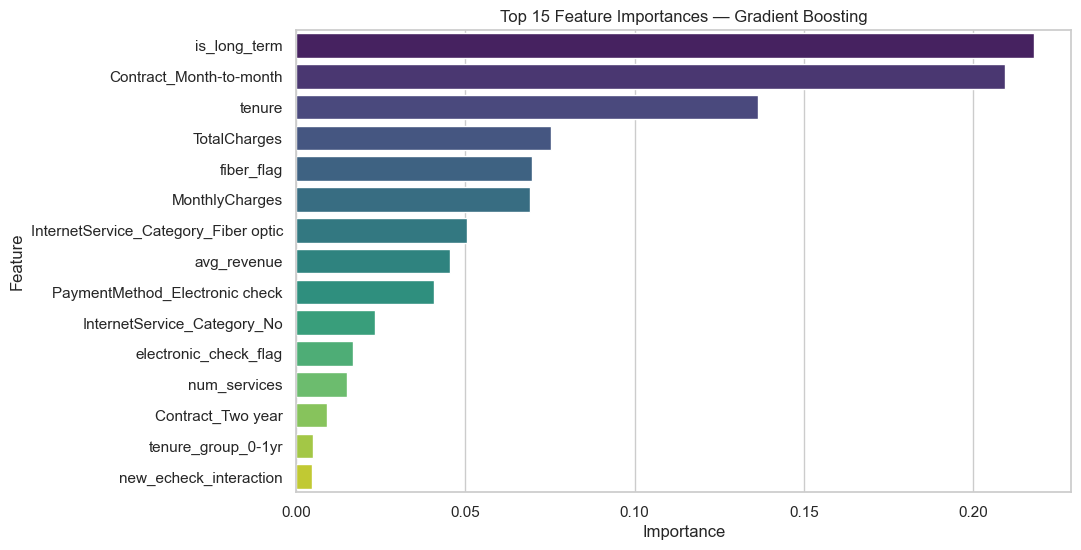

In [94]:
# Get feature names from tree pipeline
num_cols = numeric_features + engineered_features
cat_cols = tree_preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_columns_tree = list(num_cols) + list(cat_cols)

# Wrap preprocessed tree matrix as DataFrame
X_train_tree_df = pd.DataFrame(
    X_train_tree,  # preprocessed tree features
    columns=all_columns_tree
)

# Gradient Boosting Feature Importance
gb_importances = pd.DataFrame({
    "Feature": X_train_tree_df.columns,  # original feature names
    "Importance": gb.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=gb_importances, palette="viridis", hue="Feature")
plt.title("Top 15 Feature Importances — Gradient Boosting")
plt.show()

## 6.5. Reflection

### Reflection on Model Performance

1. **Which model performs best?**  
   Compare metrics like ROC-AUC, F1-score, and recall across models.

2. **Is improvement significant?**  
   Discuss differences in performance between models (e.g., Logistic Regression vs Gradient Boosting).

3. **Is recall high enough for business?**  
   Consider the cost of missing churners (false negatives).

4. **Is the model interpretable enough?**  
   Discuss trade-offs: linear model coefficients vs tree-based feature importance.

5. **Which model would you deploy?**  
   Suggest a model based on metrics, interpretability, and business impact.


### Logistic Regression

### Tree Models

# 7. Threshold & Business Optimization

# 8. Model Interpretation

# 9. Final Recommendations

# 10. Next Steps (Week 2 Teaser)